Task 1: Data Analysis

Step 1: Loading the basic Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Step 2:Load the Dataset

In [3]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Step 3: Basic Ckecks

In [4]:
print(len(x_train))

60000


In [5]:
print(len(x_test))

10000


In [6]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [7]:
print(x_train[0].shape)

(28, 28)


In [8]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

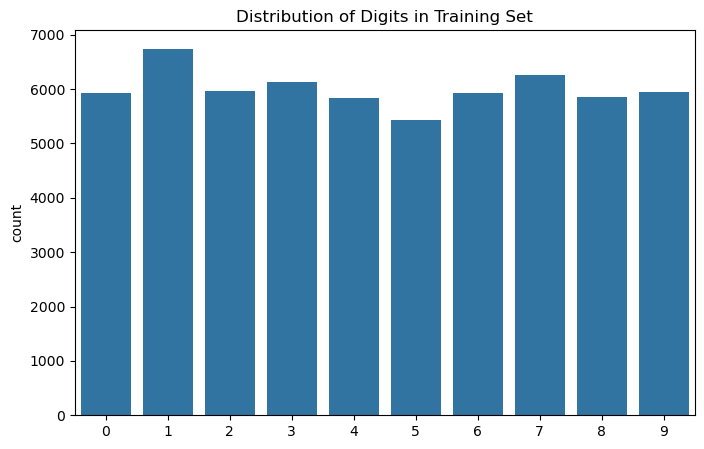

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)
plt.title("Distribution of Digits in Training Set")
plt.show()

Step 4: Visualize Sample Images

AxesImage(shape=(28, 28))


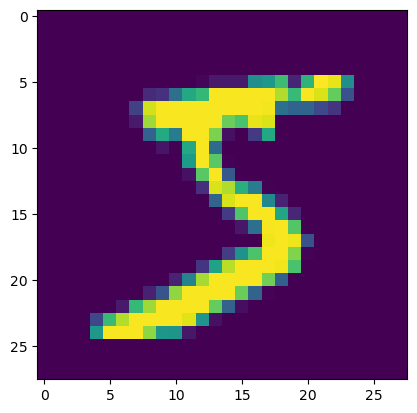

None


In [10]:
print(plt.imshow(x_train[0]))
print(plt.show())

AxesImage(shape=(28, 28))


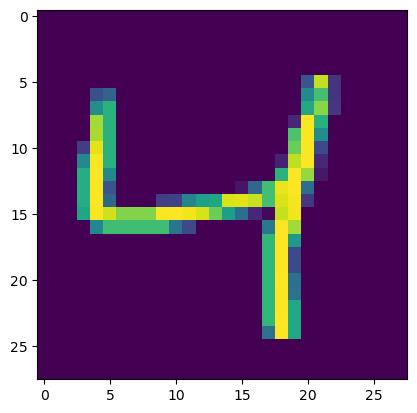

None


In [11]:
print(plt.imshow(x_train[2]))
print(plt.show())

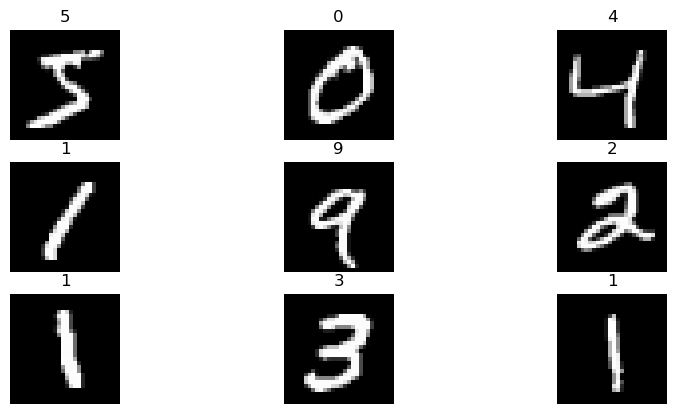

In [12]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(6,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

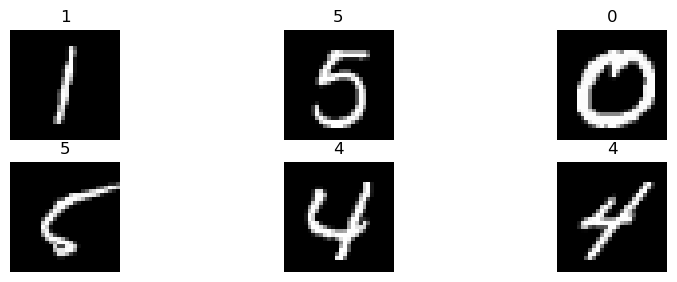

In [13]:
# choose 6 random indices
rand_indices = np.random.choice(len(x_train), 6, replace=False)

# plot random images
plt.figure(figsize=(10,10))
for i, idx in enumerate(rand_indices):
    plt.subplot(6, 3, i+1)   # 2 rows, 3 columns
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(y_train[idx])
    plt.axis('off')

plt.show()

View an Image in More Detail

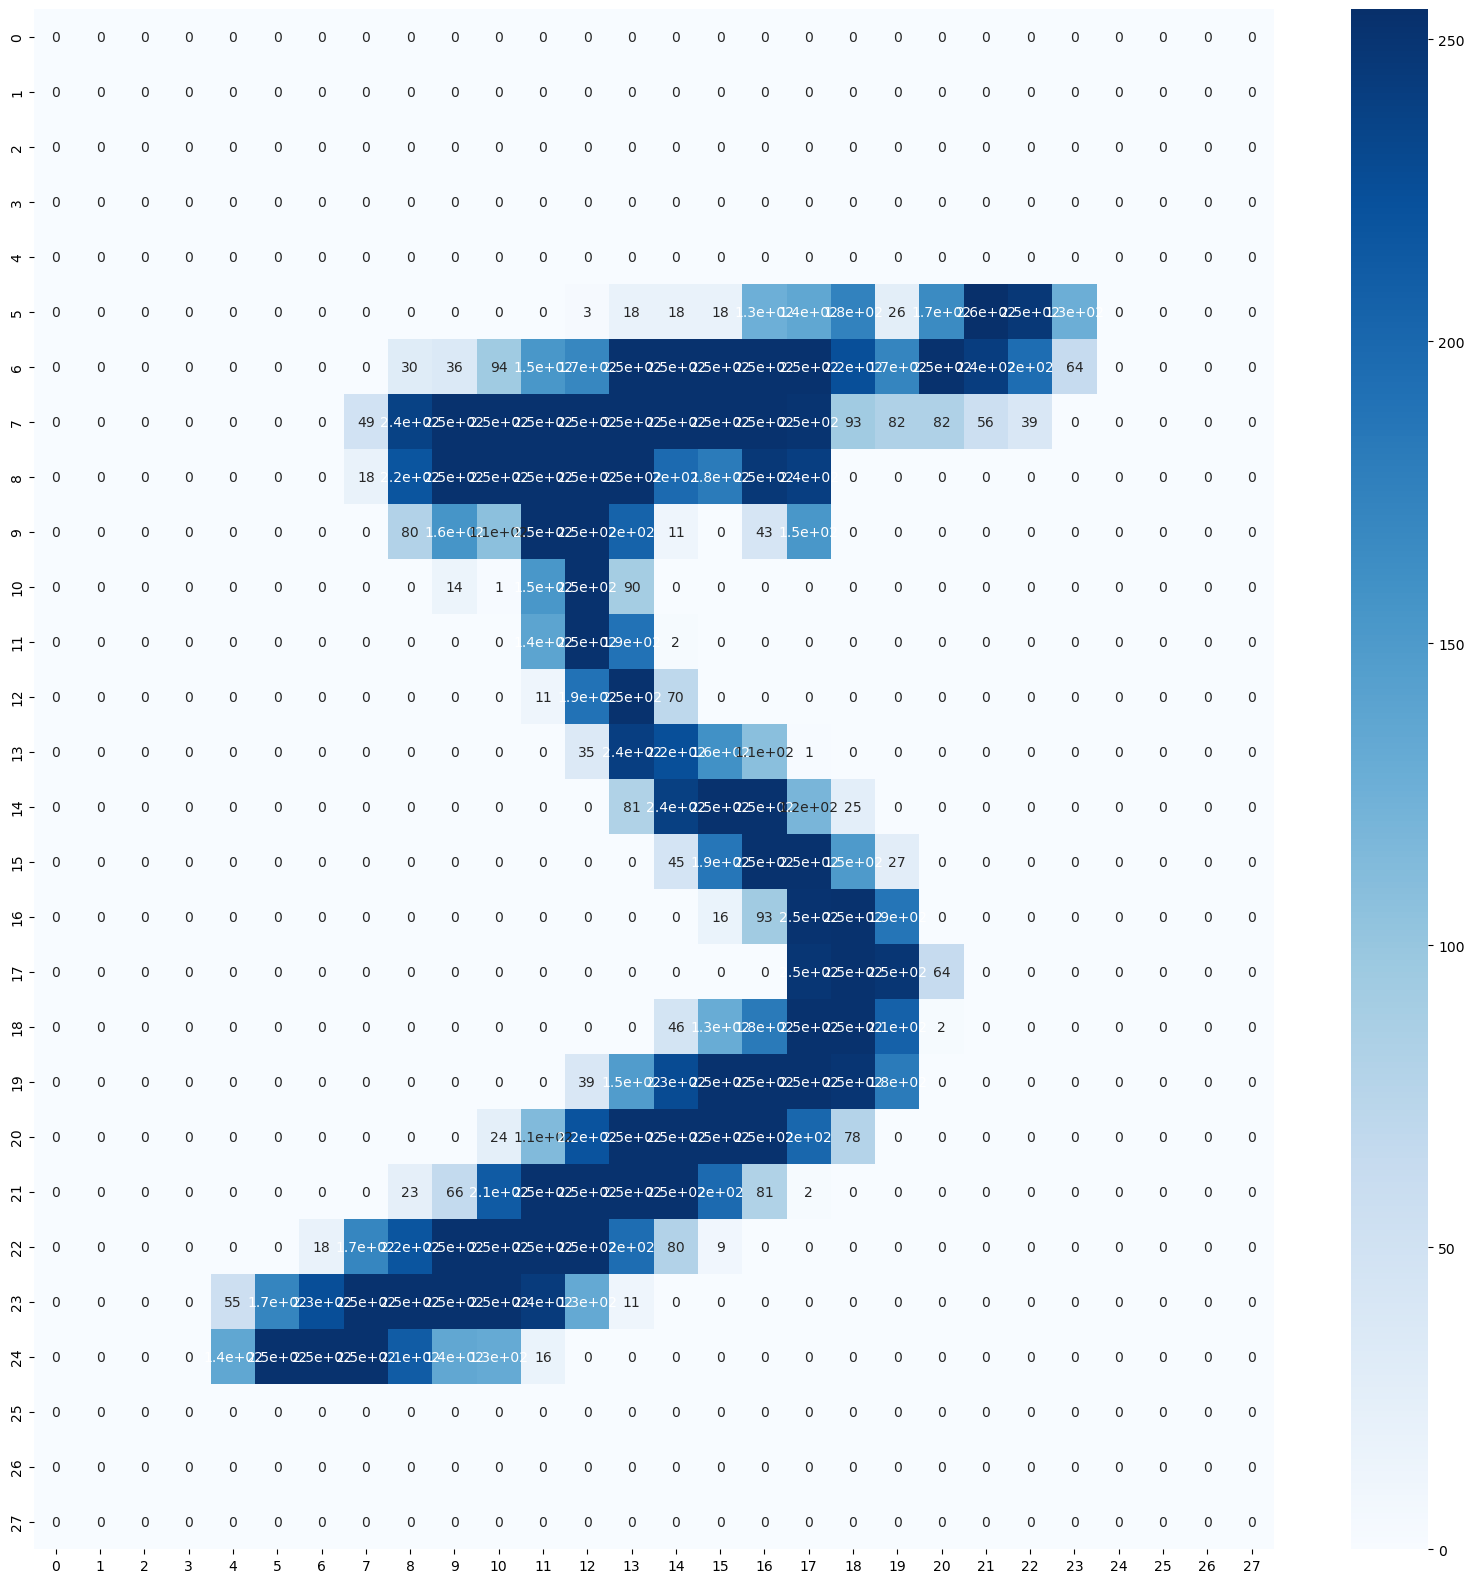

In [14]:
plt.figure(figsize=(20,20))
sns.heatmap(x_train[0],cmap='Blues',annot=True)
plt.show()

In [15]:
print(x_train.dtype)

uint8


Step 5:Data Preprocessing

In [16]:
# rescale to have values within 0 - 1 range [0,255] --> [0,1]
x_train = x_train/255.0
x_test = x_test/255.0

print('X_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_train[0].shape, 'train samples')
print(x_test[0].shape, 'test samples')

X_train shape: (60000, 28, 28)
60000 train samples
10000 test samples
(28, 28) train samples
(28, 28) test samples


In [17]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [18]:
print(x_train[0].max())
print(x_train[0].min())
print(x_train[1].max())
print(x_train[1].min())
print(x_train[59999].max())
print(x_train[59999].min())

1.0
0.0
1.0
0.0
1.0
0.0


AxesImage(shape=(28, 28))


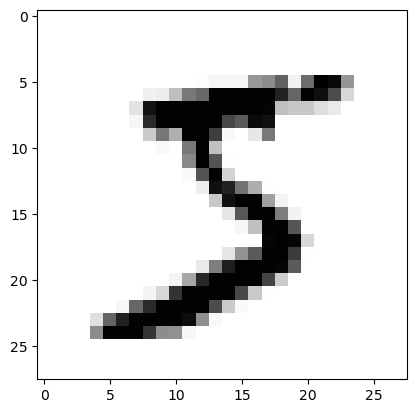

None


In [19]:
print(plt.imshow(x_train[0],cmap='Grays'))
print(plt.show())

View image after rescaling

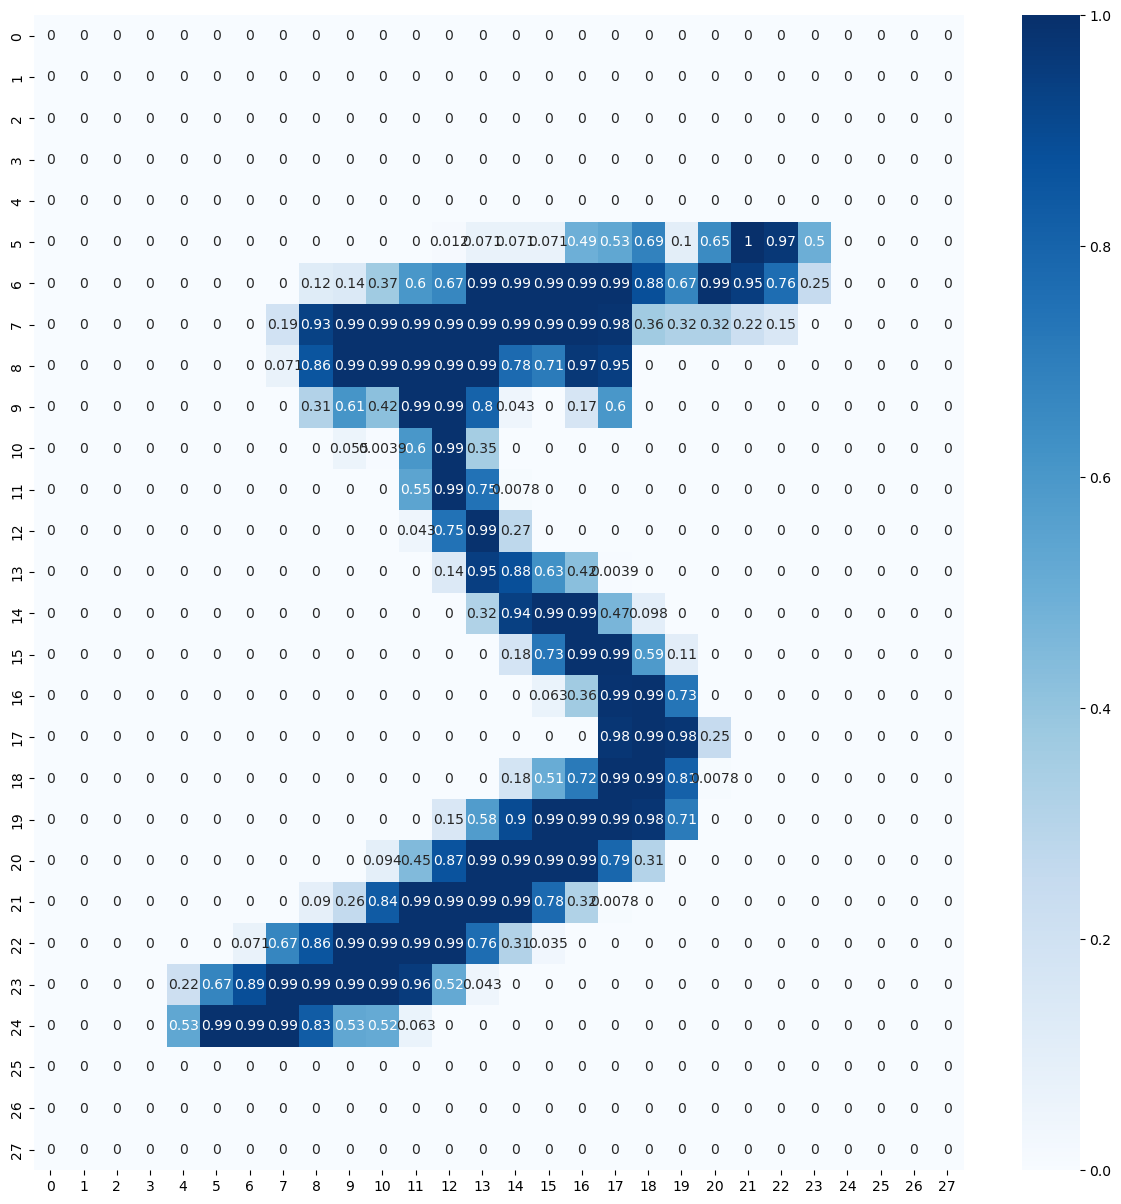

In [20]:
plt.figure(figsize=(15,15))
sns.heatmap(x_train[0],cmap='Blues',annot=True)
plt.show()

Reshape for Neural Network

In [33]:
x_train_flat = x_train.reshape(len(x_train), 28*28)
x_test_flat = x_test.reshape(len(x_test), 28*28)

In [34]:
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


In [35]:
x_train_flat[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [36]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [37]:
print(y_train[2])

4


In [38]:
print(y_train[:15])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1]


In [39]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

One-Hot Encoding

In [40]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [41]:
print(y_train_cat.shape)
print(y_test_cat.shape)

(60000, 10)
(10000, 10)


In [42]:
y_train_cat[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [43]:
import pandas as pd
pd.DataFrame(y_train_cat,columns = range(0,10))

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Step 6: Model Building

Logistic regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_flat, y_train)

y_pred_lr = lr.predict(x_test_flat)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9263


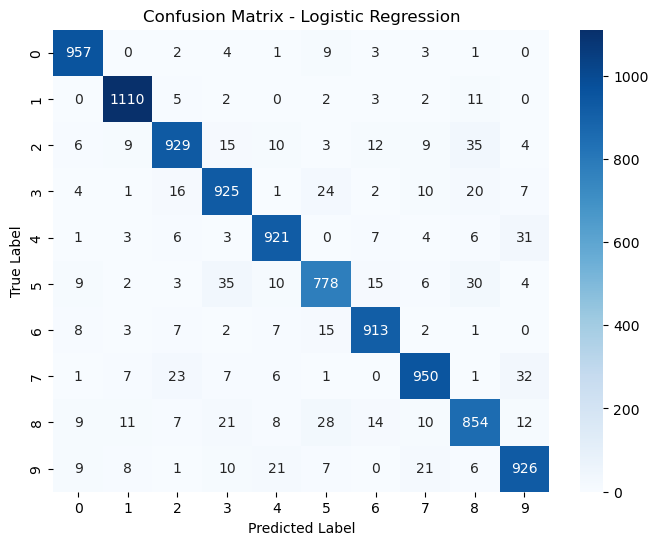

In [45]:
# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [46]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.92      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



KNN

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat, y_train)

y_pred_knn = knn.predict(x_test_flat)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9705


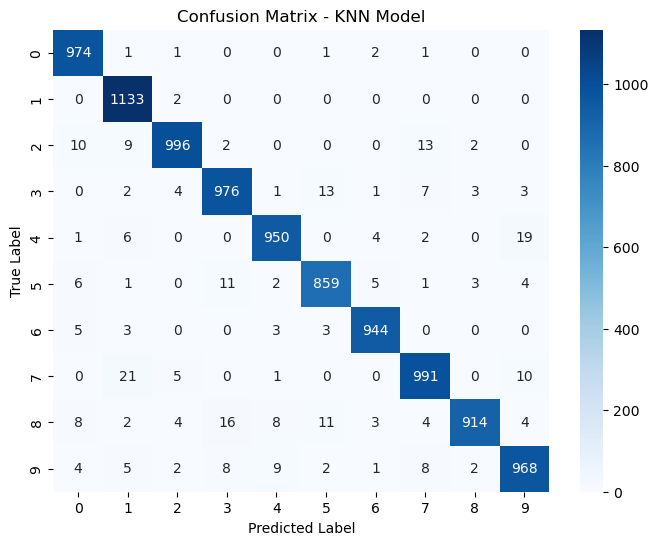

In [48]:
# Create confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



SVM

In [50]:
from sklearn.svm import SVC

svm=SVC()
svm.fit(x_train_flat,y_train)

y_pred_svm=svm.predict(x_test_flat)
print("SVM Accuracy:",accuracy_score(y_test,y_pred_svm))

SVM Accuracy: 0.9792


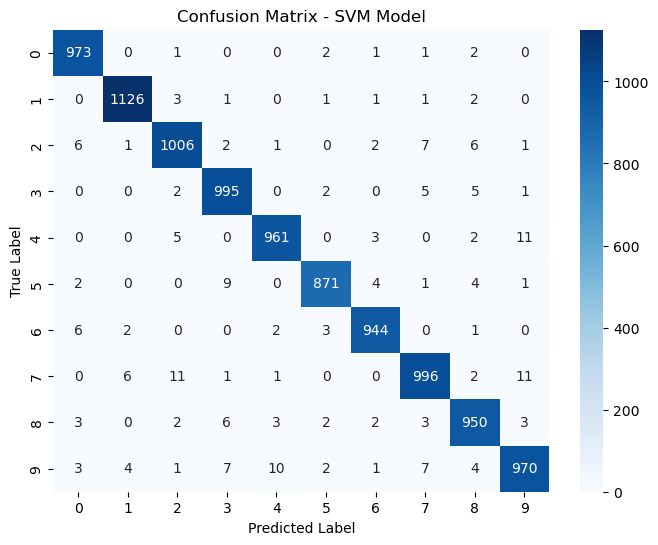

In [51]:
# Create confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



ANN

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Compile and train the model

In [54]:
# compile the model
model_ann.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# train the model
model_ann.fit(x_train_flat, y_train_cat, epochs=10, batch_size=32)

# model evaluation
loss, acc = model_ann.evaluate(x_test_flat, y_test_cat)
print("ANN Accuracy:", acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9268 - loss: 0.2461
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9686 - loss: 0.1043
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9774 - loss: 0.0742
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9825 - loss: 0.0552
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9861 - loss: 0.0440
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9888 - loss: 0.0356
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9898 - loss: 0.0304
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9915 - loss: 0.0250
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9924 - loss: 0.0226
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9938 - loss: 0.0186
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9784 - loss: 0.0905
ANN Accuracy: 0.97839999

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


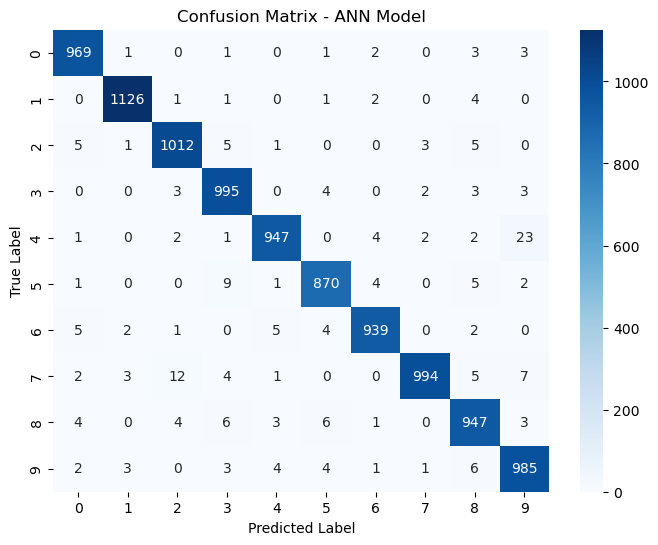

In [55]:
# Predict probabilities for test data
y_pred_ann = model_ann.predict(x_test_flat)

# Convert probabilities to class labels
y_pred_ann_classes = np.argmax(y_pred_ann, axis=1)

# True labels
y_true = np.argmax(y_test_cat, axis=1)

# Create confusion matrix
cm_ann = confusion_matrix(y_true, y_pred_ann_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - ANN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_ann_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.96      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



CNN

Reshape for CNN

In [57]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

In [58]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Compile and train the model

In [59]:
# compile the model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# train the model
model_cnn.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=32)

# model evaluation
loss, acc = model_cnn.evaluate(x_test_cnn, y_test_cat)
print("CNN Accuracy:", acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9601 - loss: 0.1293
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9863 - loss: 0.0434
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9909 - loss: 0.0291
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9933 - loss: 0.0213
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9949 - loss: 0.0161
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9912 - loss: 0.0264
CNN Accuracy: 0.9911999702453613


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


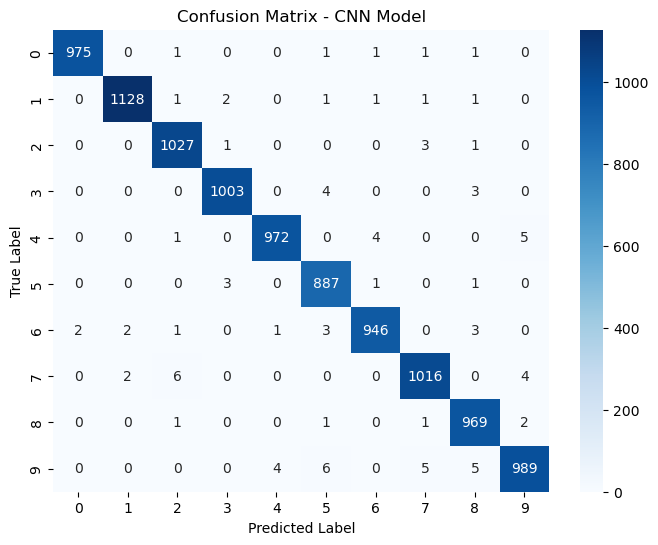

In [60]:
# Predict probabilities
y_pred_cnn = model_cnn.predict(x_test_cnn)

# Convert probabilities to class labels
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

# True labels
y_true = np.argmax(y_test_cat, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred_cnn_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_cnn_classes))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



PREDICT A NEW IMG

In [62]:
sample = x_test_cnn[5].reshape(1,28,28,1)
prediction = model_cnn.predict(sample)
print("Predicted Digit:",np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Digit: 1


In [63]:
sample = x_test_cnn[3].reshape(1,28,28,1)
prediction = model_cnn.predict(sample)

print("Predicted Digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Digit: 0


Step 7: Model Comparison Report

Model	Accuracy	Characteristics
Logistic Regression	92.58%	Simple and fast but limited for complex image patterns
KNN	97.05%	Good accuracy but computationally expensive
SVM	97.92%	High accuracy but slower training
ANN	97.86%	Learns nonlinear relationships better
CNN	99.00%	Best performance for image data


Step 8: Observations

In [ ]:
CNN
 >Best suited for image classification.
 >Extracts spatial features using convolution layers.
 >Achieves the highest accuracy.

Step 9: Challenges Faced

1.High Dimensional Data = Each image contains 28 × 28 pixels (784 features) which increases computational complexity.

2.Image Data Handling = Machine learning models cannot directly process 2D image data.

3.Multi-Class Classification = The dataset contains 10 classes (digits 0–9). One-Hot Encoding was applied to convert labels into categorical format.

4.Capturing Image Features = Flattening images removes spatial relationships between pixels.

Step 10:Conclusion

In this project, handwritten digit recognition was performed using the MNIST dataset. 
Several models including Logistic Regression, KNN, SVM, ANN, and CNN were trained and evaluated. 
The dataset was preprocessed through normalization and reshaping before model training. Model performance was evaluated using accuracy, 
confusion matrix, and classification report. Among all models, the CNN model achieved the highest accuracy because it can effectively capture spatial
features from image data, making it the most suitable model for production.